# Comparison with other baselines on the kidney cancer dataset

## Comparison with cell-type-restricted analysis

In [9]:
import os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
sc.settings.verbosity = 0

mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.linewidth": 1.0,
    "font.size": 16, "axes.titlesize": 18, "axes.labelsize": 16,
    "xtick.labelsize": 14, "ytick.labelsize": 14,
    "axes.edgecolor": "#333333", "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
})
TITLE_FS = 20; CBAR_FS = 13; GENE_TITLE_FS = 17; LEG_FS = 12

In [10]:
DATA_PATH = "/import/home2/share/yqzeng/MacSGP/data/kidney_cancer"
RES_PATH  = "/import/home2/share/yqzeng/MacSGP/results/kidney_cancer"
SECTION   = "inter"
FIG_DIR   = "/import/home2/share/yqzeng/MacSGP/revision_2/vis/2.3/figs_ctr"
IND_DIR   = os.path.join(FIG_DIR, "individual")
os.makedirs(IND_DIR, exist_ok=True)

CELLTYPES = ["B-cell","EC","Epi_PT","Epi_non-PT","Fibro","Mast","Myeloid","NK","Plasma","RCC","T-cell","pDC"]
N_PCS = 10
SEED = 42
REP_GENES = ["MGP", "ACTA2", "TAGLN", "MYL9"]   # representative within-RCC PC1 top genes (stroma origin)

def to_dense(x):
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)

In [11]:
adata = ad.read_h5ad(os.path.join(RES_PATH, "adata_inter.h5ad"))
prop = adata.obsm["proportion"]
coords = np.asarray(adata.obsm["spatial"]); X_, Y_ = coords[:, 0], -coords[:, 1]

# hard cell-type assignment
adata.obs["ct"] = pd.Categorical(prop.idxmax(axis=1))
counts = adata.obs["ct"].value_counts()
present = [c for c in CELLTYPES if c in adata.obs["ct"].cat.categories]
present = sorted(present, key=lambda c: -counts.get(c, 0))     # order by spot count
rmask = (adata.obs["ct"] == "RCC").values
rcc = prop["RCC"].values
assigned_prop = prop.max(axis=1).values                        # each spot's own-label proportion (purity)
print("argmax-label counts:\n", counts.to_string())
print(f"\nRCC-labeled spots: {rmask.sum()} ({100*rmask.mean():.0f}%) | "
      f"RCC purity mean={rcc[rmask].mean():.2f} max={rcc[rmask].max():.2f} | "
      f"spots with RCC>0.5: {(rcc>0.5).sum()}")

# stacked composition per hard label
df = prop.copy(); df["ct"] = adata.obs["ct"].values
comp_lab = df.groupby("ct", observed=True)[CELLTYPES].mean().loc[present]

# within-RCC PCA -> PC1 (oriented to +correlate with RCC purity)
sub = adata[rmask].copy()
sc.tl.pca(sub, n_comps=N_PCS, random_state=SEED)
pc1 = sub.obsm["X_pca"][:, 0]
rp = sub.obsm["proportion"]["RCC"].values
sign = 1.0 if np.corrcoef(pc1, rp)[0, 1] >= 0 else -1.0
pc1_full = np.full(adata.n_obs, np.nan); pc1_full[np.where(rmask)[0]] = pc1   # raw PC1 (matches original notebook)
load = pd.Series(sub.varm["PCs"][:, 0] * sign, index=sub.var_names)           # oriented, for top-gene readout only
print(f"\nwithin-RCC PC1: corr(PC1, RCC purity) = {abs(np.corrcoef(pc1, rp)[0,1]):.2f}")
print("PC1 high-purity-side top12:", list(load.sort_values(ascending=False).head(12).index))

# cell-type origin of representative genes (reference profiles)
basis = ad.read_h5ad(os.path.join(DATA_PATH, "adata_basis_inter.h5ad"))
Bd = pd.DataFrame(np.asarray(basis.X), index=basis.obs_names, columns=basis.var_names)
def origin_of(g):
    return Bd[g].idxmax() if g in Bd.columns else "NA"
print("representative gene origins:", {g: origin_of(g) for g in REP_GENES})

argmax-label counts:
 ct
Myeloid       613
Epi_non-PT    596
RCC           392
B-cell        258
Fibro          93
EC             51
Plasma         40
T-cell          5

RCC-labeled spots: 392 (19%) | RCC purity mean=0.34 max=0.53 | spots with RCC>0.5: 4

within-RCC PC1: corr(PC1, RCC purity) = 0.58
PC1 high-purity-side top12: ['CP', 'SOD2', 'APOC1', 'LYZ', 'TNFSF10', 'IFI30', 'SLC13A1', 'CDH6', 'PAX8', 'FCGR3A', 'STAT1', 'PLIN2']
representative gene origins: {'MGP': 'Fibro', 'ACTA2': 'Fibro', 'TAGLN': 'Fibro', 'MYL9': 'Fibro'}


In [12]:
# Nature-style categorical palette (Tableau-derived), RCC highlighted in red
CT_COLORS = {
    "B-cell":    "#4E79A7",  # blue
    "T-cell":    "#A0CBE8",  # light blue
    "NK":        "#59A14F",  # green
    "Plasma":    "#8CD17D",  # light green
    "Myeloid":   "#F28E2B",  # orange
    "Mast":      "#FFBE7D",  # light orange
    "pDC":       "#B07AA1",  # purple
    "EC":        "#9D7660",  # brown
    "Fibro":     "#D7B5A6",  # light brown
    "Epi_PT":    "#499894",  # teal
    "Epi_non-PT":"#86BCB6",  # light teal
    "RCC":       "#E15759",  # red (tumor, highlighted)
}

def clip99(v):
    v = np.asarray(v, float)
    lo, hi = np.nanpercentile(v, [1, 99])
    if hi <= lo: hi = lo + 1e-9
    return np.clip(v, lo, hi), lo, hi

def add_cbar(ax, sm, ticks=True, label=None):
    cax = ax.inset_axes([0.28, -0.08, 0.44, 0.038])
    cb = ax.figure.colorbar(sm, cax=cax, orientation="horizontal")
    if ticks:
        cb.locator = MaxNLocator(nbins=3); cb.update_ticks(); cax.tick_params(labelsize=CBAR_FS)
    else:
        cb.set_ticks([])
    if label: cb.set_label(label, fontsize=CBAR_FS, labelpad=3)
    cb.outline.set_linewidth(0.6)
    return cb

def _spatial_axes(ax):
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)

def draw_labels(ax, spot=9, legend=True):
    for c in present:
        m = (adata.obs["ct"].values == c)
        ax.scatter(X_[m], Y_[m], s=spot, color=CT_COLORS[c], linewidths=0, label=c)
    _spatial_axes(ax); ax.set_title("Hard cell-type labels", fontsize=TITLE_FS, pad=10)
    if legend:
        ax.legend(loc="upper left", bbox_to_anchor=(-0.1, 1.0), fontsize=10.5, frameon=False,
                  ncol=1, markerscale=1.9, handletextpad=0.3, labelspacing=0.32, borderpad=0.2)

def draw_hist(ax):
    ax.hist(assigned_prop, bins=40, color="#4E79A7", edgecolor="white", linewidth=0.3)
    med = float(np.median(assigned_prop))
    ax.axvline(med, color="#E15759", ls="--", lw=2.0, label=f"median = {med:.2f}")
    # ax.axvline(0.5, color="0.35", ls=":", lw=1.8, label="purity = 0.5")
    ax.set_xlabel("Probability of the most likely cell type", fontsize=15)
    ax.set_ylabel("Frequency", fontsize=15)
    # ax.set_title("Probability of the hard-labeled spots", fontsize=TITLE_FS, pad=6)
    ax.tick_params(labelsize=13)
    ax.legend(fontsize=12, frameon=False)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

def draw_prop_full(ax, v, title, cmap="Reds"):
    vc, lo, hi = clip99(v)
    sm = ax.scatter(X_, Y_, c=vc, cmap=cmap, s=9, vmin=lo, vmax=hi, linewidths=0)
    _spatial_axes(ax); ax.set_title(title, fontsize=TITLE_FS, pad=10); add_cbar(ax, sm)
    return sm

def draw_masked(ax, v_full, title, cmap="viridis", italic=False, spot=9,
                normalize=False, cbar_ticks=True, cbar_label=None):
    vv = np.asarray(v_full, float)
    grey = ~rmask
    ax.scatter(X_[grey], Y_[grey], s=4, color="0.85", linewidths=0)
    vsel, lo, hi = clip99(vv[rmask])
    if normalize:
        vsel = (vsel - lo) / (hi - lo + 1e-12); lo, hi = 0.0, 1.0
    sm = ax.scatter(X_[rmask], Y_[rmask], c=vsel, cmap=cmap, s=spot, vmin=lo, vmax=hi, linewidths=0)
    _spatial_axes(ax)
    ax.set_title(title, fontsize=(GENE_TITLE_FS if italic else TITLE_FS), pad=8,
                 fontstyle=("italic" if italic else "normal"))
    add_cbar(ax, sm, ticks=cbar_ticks, label=cbar_label)
    return sm

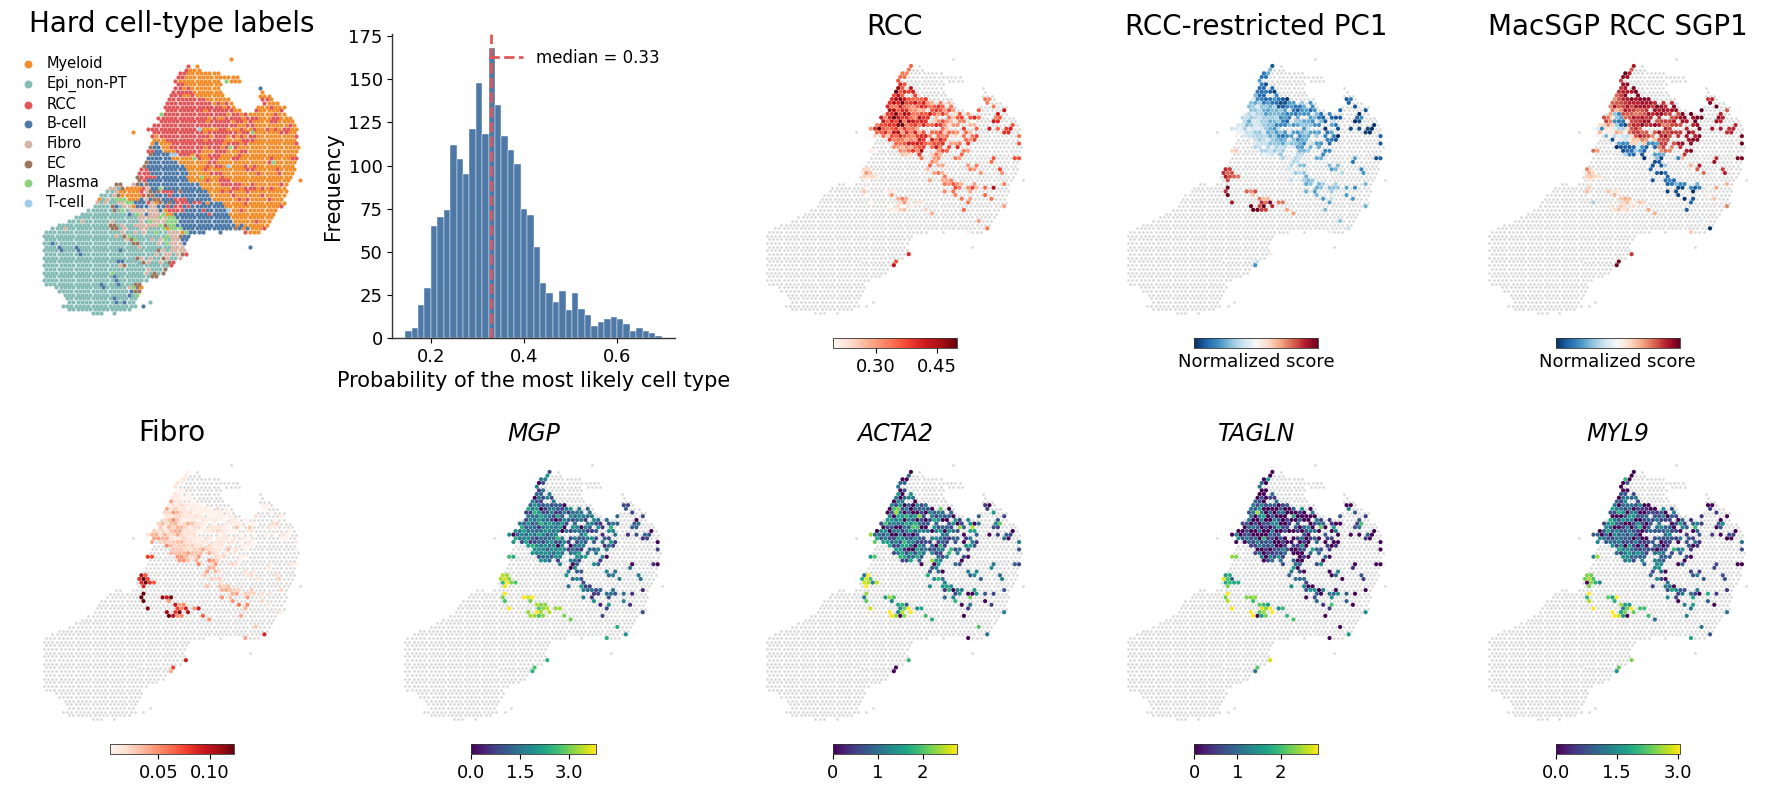

composite saved -> /import/home2/share/yqzeng/MacSGP/revision_2/vis/2.3/figs_ctr/celltype_restricted_panel.png


In [17]:
fig = plt.figure(figsize=(18, 8))
sf = fig.subfigures(2, 1, height_ratios=[1.0, 1.0], hspace=0.0)
fac_full = np.full(adata.n_obs, np.nan); fac_full[rmask] = adata.obsm["factor"]["RCC"].values[rmask]

# ---- Row 1: labels | purity | RCC | RCC-restricted PC1 | MacSGP SGP ----
a0 = sf[0].subplots(1, 5)
sf[0].subplots_adjust(left=0.03, right=0.99, top=0.92, bottom=0.16, wspace=0.28)
draw_labels(a0[0])
draw_hist(a0[1])
draw_masked(a0[2], rcc, "RCC", cmap="Reds")
draw_masked(a0[3], pc1_full, "RCC-restricted PC1", cmap="RdBu_r",
            normalize=True, cbar_ticks=False, cbar_label="Normalized score")
draw_masked(a0[4], fac_full, "MacSGP RCC SGP1", cmap="RdBu_r",
            normalize=True, cbar_ticks=False, cbar_label="Normalized score")

# ---- Row 2: Fibro + representative PC1 top genes (RCC-labeled spots) ----
a1 = sf[1].subplots(1, 5)
sf[1].subplots_adjust(left=0.03, right=0.99, top=0.95, bottom=0.10, wspace=0.28)
fib_full = prop["Fibro"].values.copy(); fib_full[~rmask] = np.nan
draw_masked(a1[0], fib_full, "Fibro", cmap="Reds")
for ax, g in zip(a1[1:], REP_GENES):
    gv = to_dense(adata[:, g].X).ravel().astype(float); gv[~rmask] = np.nan
    draw_masked(ax, gv, g, cmap="viridis", italic=True)

fig.savefig(os.path.join(FIG_DIR, "celltype_restricted_panel.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(FIG_DIR, "celltype_restricted_panel.png"), dpi=300, bbox_inches="tight")
plt.show()
print("composite saved ->", os.path.join(FIG_DIR, "celltype_restricted_panel.png"))

## Comparison with domain-based analysis

In [ ]:
import os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
sc.settings.verbosity = 0

# ---- shared style (from 2.2 reference panel), enlarged for publication ----
mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.linewidth": 1.0,
    "font.size": 16, "axes.titlesize": 18, "axes.labelsize": 16,
    "xtick.labelsize": 14, "ytick.labelsize": 14,
    "axes.edgecolor": "#333333", "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
})
TITLE_FS = 20; CBAR_FS = 13; BAR_TICK_FS = 14; TERM_FS = 13; GENE_TITLE_FS = 16

In [ ]:
DATA_PATH = "/import/home2/share/yqzeng/MacSGP/data/kidney_cancer"
RES_PATH  = "/import/home2/share/yqzeng/MacSGP/results/kidney_cancer"
SECTION   = "inter"
ST_FILE   = "visium_1.h5ad"
DOMBASE   = os.path.join(RES_PATH, SECTION, "domain_based")   # saved enrichment lives here
FIG_DIR   = "/import/home2/share/yqzeng/MacSGP/revision_2/vis/2.3/figs"
IND_DIR   = os.path.join(FIG_DIR, "individual")
os.makedirs(IND_DIR, exist_ok=True)

TARGET_DOMAINS = 4
RESOLUTIONS = [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
N_HVG, N_PCS, SEED = 2000, 30, 0
LIB = "MSigDB_Hallmark_2020"
TOPN_PATH = 8               # pathway terms per domain
DISP_ORDER = ["3", "0", "2", "1"]   # requested display order

CELLTYPES = ["B-cell","EC","Epi_PT","Epi_non-PT","Fibro","Mast","Myeloid","NK","Plasma","RCC","T-cell","pDC"]
CAT = {"RCC":"Tumor(RCC)","Epi_PT":"Epithelial","Epi_non-PT":"Epithelial",
       "B-cell":"Immune","T-cell":"Immune","NK":"Immune","Myeloid":"Immune",
       "Mast":"Immune","Plasma":"Immune","pDC":"Immune","EC":"Stromal","Fibro":"Stromal"}
BAR_COLOR = "#4c72b0"      # uniform pathway bar color (no RCC highlight)

def to_dense(x):
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)

In [ ]:
adata = sc.read_h5ad(os.path.join(DATA_PATH, ST_FILE))
adata.var_names_make_unique()

sc.pp.highly_variable_genes(adata, n_top_genes=N_HVG)
ah = adata[:, adata.var.highly_variable].copy()
sc.pp.scale(ah, max_value=10)
sc.tl.pca(ah, n_comps=N_PCS, random_state=SEED)
sc.pp.neighbors(ah, n_neighbors=15, n_pcs=N_PCS, random_state=SEED)

ndom = {}
for r in RESOLUTIONS:
    sc.tl.leiden(ah, resolution=r, key_added=f"leiden_{r}", random_state=SEED,
                 flavor="igraph", n_iterations=2, directed=False)
    ndom[r] = int(ah.obs[f"leiden_{r}"].nunique())
best_r = min(RESOLUTIONS, key=lambda r: (abs(ndom[r] - TARGET_DOMAINS), r))
adata.obs["domain"] = pd.Categorical(ah.obs[f"leiden_{best_r}"].values)

prop = adata.obsm["proportion"].copy(); prop["domain"] = adata.obs["domain"].values
dom_rcc = prop.groupby("domain", observed=True)["RCC"].mean().sort_values(ascending=False)
rcc_domains = list(dom_rcc.index[:2])            # two RCC-rich domains (D3, D0)
DOMS = [d for d in DISP_ORDER if d in adata.obs["domain"].cat.categories]
NEW_NAME = {d: f"D{i+1}" for i, d in enumerate(DOMS)}   # relabel by display order: 3->D1,0->D2,2->D3,1->D4
print(f"resolution={best_r} -> {len(DOMS)} domains | display order = {DOMS} | relabel = {NEW_NAME} | RCC-rich = {rcc_domains}")
print("mean RCC proportion per domain:\n", dom_rcc.round(3).to_string())

resolution=0.2 -> 4 domains | display order = ['3', '0', '2', '1'] | relabel = {'3': 'D1', '0': 'D2', '2': 'D3', '1': 'D4'} | RCC-rich = ['3', '0']
mean RCC proportion per domain:
 domain
3    0.291
0    0.240
2    0.138
1    0.053


In [ ]:
# composition per domain (domains x celltypes)
comp = adata.obsm["proportion"].copy(); comp["domain"] = adata.obs["domain"].values
comp_mean = comp.groupby("domain", observed=True)[CELLTYPES].mean().loc[DOMS]

# one-vs-rest DE -> up markers per domain
sc.tl.rank_genes_groups(adata, "domain", method="wilcoxon", key_added="de")
de = sc.get.rank_genes_groups_df(adata, group=None, key="de")
def up_genes(d, n=200):
    return (de[(de.group==d)&(de.pvals_adj<0.05)&(de.logfoldchanges>1)]
            .nlargest(n, "scores")["names"].tolist())
domain_up = {d: up_genes(d) for d in DOMS}

# Jaccard overlap of domain marker sets (ordered)
sets = {d: set(domain_up[d]) for d in DOMS}
J = pd.DataFrame(index=DOMS, columns=DOMS, dtype=float)
for a in DOMS:
    for b in DOMS:
        u = len(sets[a] | sets[b]); J.loc[a, b] = (len(sets[a] & sets[b]) / u) if u else 0.0
J = J.astype(float)

# representative marker per domain + cell-type origin
basis = ad.read_h5ad(os.path.join(DATA_PATH, "adata_basis_inter.h5ad"))
B = pd.DataFrame(np.asarray(basis.X), index=basis.obs_names, columns=basis.var_names)
def origin_of(g):
    return B[g].idxmax() if g in B.columns else "NA"
rep_gene = {}
for d in DOMS:
    top = de[(de.group==d)&(de.pvals_adj<0.05)&(de.logfoldchanges>1)].nlargest(1,"scores")["names"]
    rep_gene[d] = top.iloc[0] if len(top) else domain_up[d][0]

# DE genes shared by the two RCC-rich domains (D3 & D0)
shared = sets[rcc_domains[0]] & sets[rcc_domains[1]]
PREF = ["HLA-DRA","CD74","APOE","C3","B2M","APOC1","TNFSF10","HLA-DRB1"]
shared_rep = [g for g in PREF if g in shared and g in adata.var_names]
if len(shared_rep) < 4:
    extra = [g for g in sorted(shared) if g in adata.var_names and g not in shared_rep]
    shared_rep += extra
shared_rep = shared_rep[:4]
print("representative gene per domain:", {f"D{d}": (rep_gene[d], origin_of(rep_gene[d])) for d in DOMS})
print(f"shared DE genes (D{rcc_domains[0]} & D{rcc_domains[1]}): n={len(shared)} | showing {shared_rep}")

representative gene per domain: {'D3': ('SOD2', 'RCC'), 'D0': ('VCAM1', 'RCC'), 'D2': ('ADIRF', 'EC'), 'D1': ('WFDC2', 'Epi_non-PT')}
shared DE genes (D3 & D0): n=80 | showing ['HLA-DRA', 'CD74', 'APOE', 'C3']


In [ ]:
# load saved enrichment (Enrichr; avoids re-querying the network)
enr = pd.read_csv(os.path.join(DOMBASE, "4_domain_enrichment.csv"))
enr["domain"] = enr["domain"].astype(str)
print("enrichment libs:", enr["Gene_set"].unique(), "| using:", LIB)

enrichment libs: ['MSigDB_Hallmark_2020' 'GO_Biological_Process_2021'] | using: MSigDB_Hallmark_2020


In [ ]:
coords = np.asarray(adata.obsm["spatial"]); X_, Y_ = coords[:, 0], -coords[:, 1]
DOM_CMAP = plt.get_cmap("tab10")
DOM_COL = {d: DOM_CMAP(i % 10) for i, d in enumerate(sorted(adata.obs["domain"].cat.categories, key=int))}

def clip99(v):
    v = np.asarray(v, float).ravel()
    lo, hi = np.percentile(v, [1, 99])
    if hi <= lo: hi = lo + 1e-9
    return np.clip(v, lo, hi), lo, hi

def add_cbar(ax, sm, ticks=True, label=None):
    cax = ax.inset_axes([0.28, -0.08, 0.44, 0.038])
    cb = ax.figure.colorbar(sm, cax=cax, orientation="horizontal")
    if ticks:
        cb.locator = MaxNLocator(nbins=3); cb.update_ticks(); cax.tick_params(labelsize=CBAR_FS)
    else:
        cb.set_ticks([])
    if label: cb.set_label(label, fontsize=CBAR_FS, labelpad=3)
    cb.outline.set_linewidth(0.6)
    return cb

def draw_domains(ax, spot=9):
    for d in DOMS:
        m = adata.obs["domain"].values == d
        ax.scatter(X_[m], Y_[m], s=spot, color=DOM_COL[d], linewidths=0, label=NEW_NAME[d])
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_title("Spatial domains", fontsize=TITLE_FS, pad=10)
    ax.legend(markerscale=2.6, fontsize=13, loc="upper left", frameon=False,
              handletextpad=0.25, borderpad=0.2, labelspacing=0.3)

def draw_gene(ax, g, spot=9, name=True):
    v = to_dense(adata[:, g].X).ravel().astype(float)
    vc, lo, hi = clip99(v)
    sm = ax.scatter(X_, Y_, c=vc, cmap="viridis", s=spot, vmin=lo, vmax=hi, linewidths=0)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    if name: ax.set_title(g, fontsize=GENE_TITLE_FS, pad=6, fontstyle="italic")
    add_cbar(ax, sm, ticks=True)
    return sm

def draw_comp(ax, cbar_ax):
    sns.heatmap(comp_mean, cmap="Reds", vmin=0, cbar=True, cbar_ax=cbar_ax,
                cbar_kws={"label": "mean proportion"},
                yticklabels=[NEW_NAME[d] for d in DOMS], xticklabels=CELLTYPES, ax=ax,
                linewidths=0.4, linecolor="white")
    ax.set_title("Cell-type composition", fontsize=TITLE_FS, pad=10)
    ax.set_ylabel(""); ax.set_xlabel("")
    ax.set_xticklabels(CELLTYPES, rotation=45, ha="right", fontsize=13)
    ax.tick_params(axis="y", labelrotation=0, labelsize=15)
    cbar_ax.tick_params(labelsize=CBAR_FS); cbar_ax.yaxis.label.set_size(CBAR_FS)

def draw_jaccard(ax, cbar_ax):
    sns.heatmap(J, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar=True,
                cbar_ax=cbar_ax, cbar_kws={"label": "Jaccard"},
                xticklabels=[NEW_NAME[d] for d in DOMS], yticklabels=[NEW_NAME[d] for d in DOMS],
                ax=ax, annot_kws={"fontsize": 14}, linewidths=0.6, linecolor="white")
    ax.set_title("DE-gene overlap", fontsize=TITLE_FS, pad=10)
    ax.tick_params(axis="x", labelrotation=0, labelsize=15)
    ax.tick_params(axis="y", labelrotation=0, labelsize=15)
    cbar_ax.tick_params(labelsize=CBAR_FS); cbar_ax.yaxis.label.set_size(CBAR_FS)

def draw_pathway(ax, d, topn=TOPN_PATH):
    s = (enr[(enr.domain == d) & (enr.Gene_set == LIB) & (enr["Adjusted P-value"] < 0.05)]
         .nsmallest(topn, "Adjusted P-value"))
    if len(s) == 0:
        ax.text(0.5, 0.5, "no significant term", ha="center", va="center", fontsize=12)
        ax.set_axis_off(); ax.set_title(f"Domain {NEW_NAME[d]}", fontsize=TITLE_FS); return
    terms = [t.split(" (GO")[0][:40] for t in s["Term"]][::-1]
    vals = (-np.log10(s["Adjusted P-value"]))[::-1]
    ax.barh(range(len(terms)), vals, color=BAR_COLOR, height=0.74, edgecolor="none")
    ax.set_yticks(range(len(terms))); ax.set_yticklabels(terms, fontsize=TERM_FS)
    ax.set_xlabel("$-\log_{10}$ adj-$P$", fontsize=15)
    ax.set_title(f"Domain {NEW_NAME[d]}", fontsize=TITLE_FS, pad=8)
    ax.tick_params(axis="x", labelsize=13)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

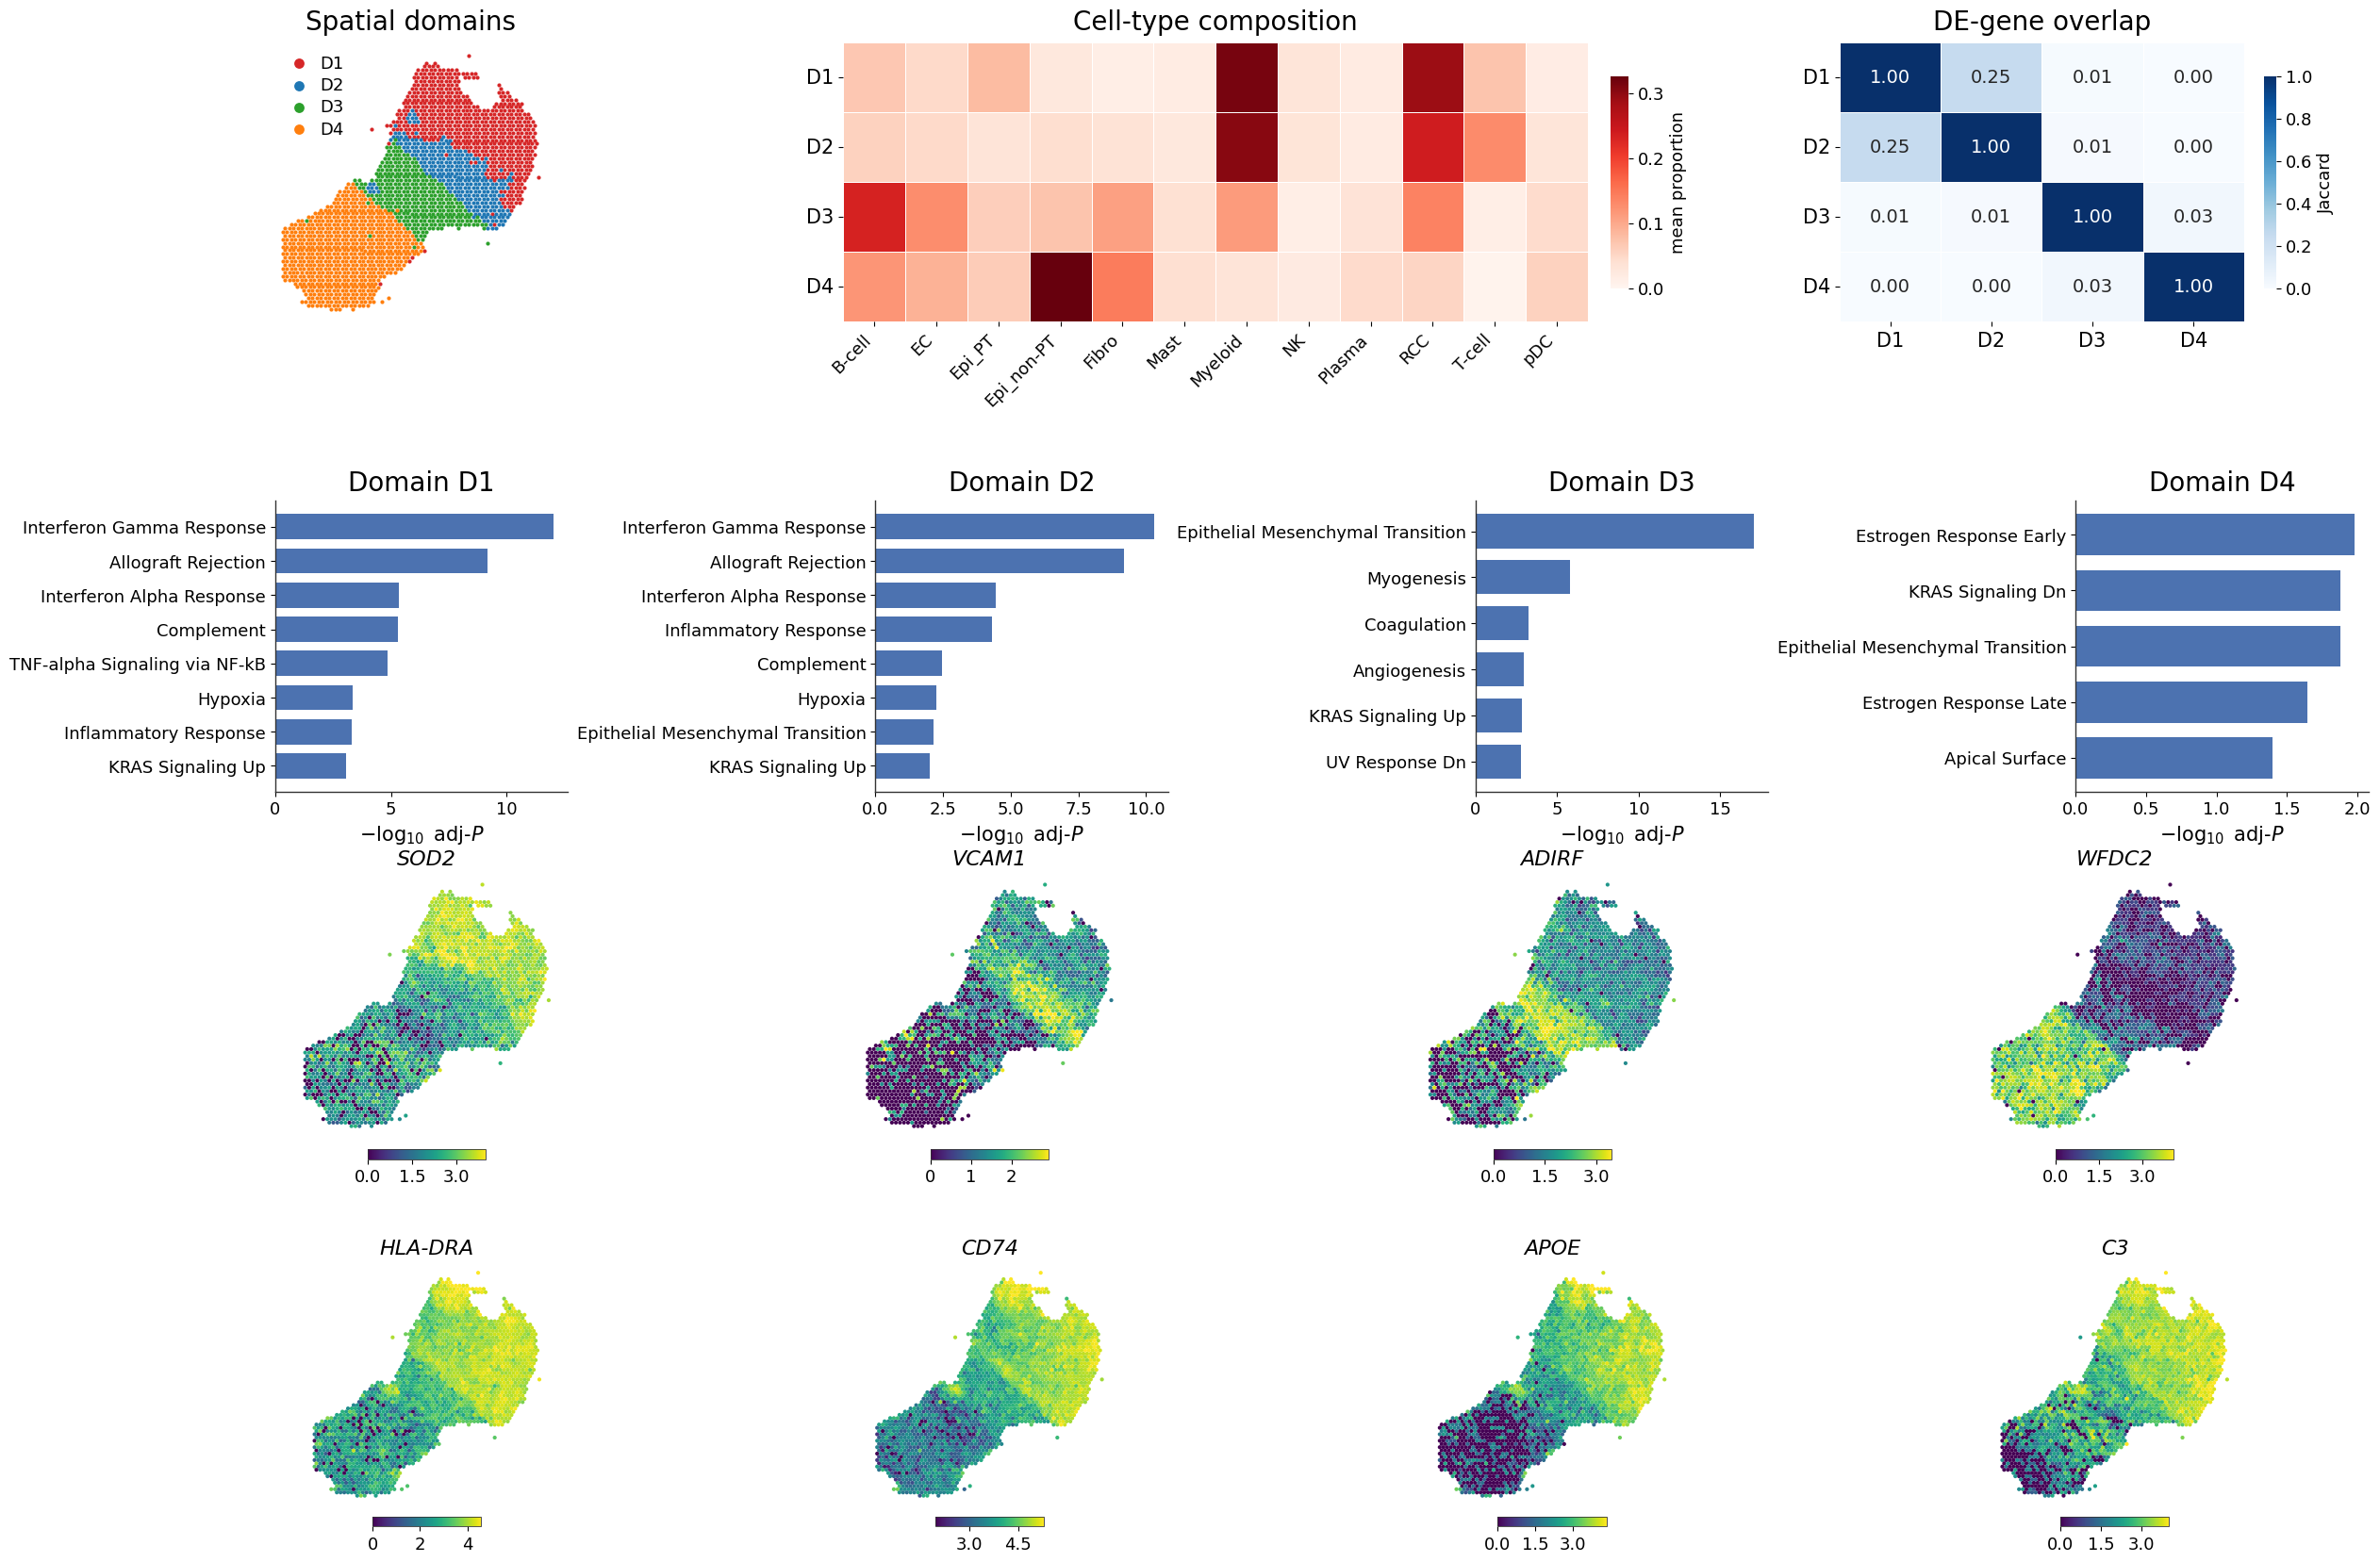

composite saved -> /import/home2/share/yqzeng/MacSGP/revision_2/vis/2.3/figs/domain_based_panel.png


In [ ]:
fig = plt.figure(figsize=(24, 16.5))
sf = fig.subfigures(4, 1, height_ratios=[1.05, 1.0, 0.82, 0.82], hspace=0.02)

# ---- Row 1: domains | composition | DE-gene overlap ----
a0 = sf[0].subplots(1, 3, gridspec_kw={"width_ratios": [0.85, 1.75, 0.95]})
sf[0].subplots_adjust(left=0.04, right=0.93, top=0.90, bottom=0.26, wspace=0.50)
draw_domains(a0[0])
cax_c = a0[1].inset_axes([1.03, 0.12, 0.025, 0.76]); draw_comp(a0[1], cax_c)
cax_j = a0[2].inset_axes([1.05, 0.12, 0.03, 0.76]);  draw_jaccard(a0[2], cax_j)

# ---- Row 2: pathway enrichment per domain (order 3,0,2,1) ----
a1 = sf[1].subplots(1, 4)
sf[1].subplots_adjust(left=0.06, right=0.985, top=0.86, bottom=0.16, wspace=1.05)
#sf[1].suptitle("Pathway enrichment of domain markers (Hallmark)", fontsize=TITLE_FS, y=1.0)
for ax, d in zip(a1, DOMS):
    draw_pathway(ax, d)

# ---- Row 3: representative marker per domain ----
a2 = sf[2].subplots(1, 4)
sf[2].subplots_adjust(left=0.03, right=0.97, top=0.98, bottom=0.20, wspace=0.28)
for ax, d in zip(a2, DOMS):
    draw_gene(ax, rep_gene[d])

# ---- Row 4: DE genes shared by the two RCC-rich domains ----
a3 = sf[3].subplots(1, 4)
sf[3].subplots_adjust(left=0.03, right=0.97, top=0.86, bottom=0.14, wspace=0.28)
for ax, g in zip(a3, shared_rep):
    draw_gene(ax, g)

fig.savefig(os.path.join(FIG_DIR, "domain_based_panel.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(FIG_DIR, "domain_based_panel.png"), dpi=300, bbox_inches="tight")
plt.show()
print("composite saved ->", os.path.join(FIG_DIR, "domain_based_panel.png"))

## Comparison with factor methods

In [ ]:
import os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import spearmanr
from cmcrameri import cm
sc.settings.verbosity = 0

# ---- shared style (from domain_based_panel.ipynb) ----
mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.linewidth": 1.0,
    "font.size": 16, "axes.titlesize": 18, "axes.labelsize": 16,
    "xtick.labelsize": 14, "ytick.labelsize": 14,
    "axes.edgecolor": "#333333", "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
})
TITLE_FS = 20; CBAR_FS = 13; BAR_TICK_FS = 14

DATA = "/import/home2/share/yqzeng/MacSGP/data/kidney_cancer"
RES  = "/import/home2/share/yqzeng/MacSGP/results/kidney_cancer"
FIG_DIR = "/import/home2/share/yqzeng/MacSGP/revision_2/vis/2.3/figs_factor"
IND_DIR = os.path.join(FIG_DIR, "individual")
os.makedirs(IND_DIR, exist_ok=True)

METHODS=["nmf","mofa","spicemix","stamp"]
MLAB={"nmf":"NMF","mofa":"MOFA","spicemix":"SpiceMix","stamp":"STAMP"}
TOPN=100
PT_GENES=["ACSM2B","NAT8","GSTA1","GSTA2","ACSM2A","LGALS2","CUBN","PEPD","KHK","PDZK1","BBOX1",
          "ANPEP","SLC6A13","GAL3ST1","SLC5A12","PRAP1","AQP1","CXCL14","SMIM24","CDHR5","GPX3",
          "GAMT","PCSK1N","LRP2","SLC17A3","TMEM27","TSPAN1"]
EMT_GENES=["CAV1","TGM2","FSTL3","SERPINE1","FLNA","KRT19","C3","S100A6","EMP3","MT2A","TM4SF1",
           "TGFBI","SMIM3","ITGA3","LGALS1","MARCKSL1","BIRC3","LOX","ANXA2","MMP7"]

def corr(a,b):
    a=np.asarray(a,float); b=np.asarray(b,float)
    m=np.isfinite(a)&np.isfinite(b)
    return spearmanr(a[m],b[m]).correlation if m.sum()>2 else np.nan

In [ ]:
v=sc.read_h5ad(os.path.join(DATA,"visium_1.h5ad")); names=list(v.obs_names)
coords=np.asarray(v.obsm["spatial"]); X_,Y_=coords[:,0],-coords[:,1]
prop=v.obsm["proportion"]; rcc_prop=prop["RCC"].values

ai=ad.read_h5ad(os.path.join(RES,"adata_inter.h5ad"))
ai.obs_names=[n.replace("-slice0","") for n in ai.obs_names]
mac_fac=ai.obsm["factor"].reindex(names)["RCC"].values
mac_load=ai.varm["loading"]["RCC"].copy(); mac_load.index=ai.var_names

FAC ={m:pd.read_csv(os.path.join(RES,"inter",m,"factors.csv"),  index_col=0).reindex(names) for m in METHODS}
LOAD={m:pd.read_csv(os.path.join(RES,"inter",m,"loadings.csv"), index_col=0) for m in METHODS}

B=ad.read_h5ad(os.path.join(DATA,"adata_basis_inter.h5ad"))
Bd=pd.DataFrame(np.asarray(B.X),index=B.obs_names,columns=B.var_names)
eps=1e-6; rcc_spec=np.log2((Bd.loc["RCC"]+eps)/(Bd.drop("RCC").mean(0)+eps))

PT =[g for g in PT_GENES  if g in mac_load.index]
EMT=[g for g in EMT_GENES if g in mac_load.index]
print(f"spots={len(names)} | PT present={len(PT)} | EMT present={len(EMT)}")

spots=2048 | PT present=26 | EMT present=16


In [ ]:
# match each baseline's factor to the RCC identity signature (signed-max Spearman, matches analysis_bench)
def rcc_matched(m):
    L=LOAD[m]; shared=[g for g in L.index if g in rcc_spec.index]
    sp={c:spearmanr(L.loc[shared,c].values,rcc_spec.loc[shared].values).correlation for c in L.columns}
    bf=max(sp,key=lambda c: sp[c] if sp[c]==sp[c] else -9)
    return bf, (1.0 if sp[bf]>=0 else -1.0), sp[bf]
rcc_prog={m:rcc_matched(m)[:2] for m in METHODS}
print("RCC-matched factors:",{MLAB[m]:rcc_prog[m][0] for m in METHODS})
# recovery: PT / EMT markers among the top-TOPN |loading| genes of each RCC program
def recovery(load_series):
    top=set(load_series.abs().sort_values(ascending=False).index[:TOPN])
    return sorted(set(PT)&top), sorted(set(EMT)&top)
progs_load={"MacSGP":mac_load}
for m in METHODS:
    bf,_=rcc_prog[m]; progs_load[MLAB[m]]=LOAD[m][bf]
rows=[]
for k,s in progs_load.items():
    p,e=recovery(s); rows.append({"method":k,"PT_recovered":len(p),"EMT_recovered":len(e)})
rec_tab=pd.DataFrame(rows)
print(rec_tab.to_string(index=False))

RCC-matched factors: {'NMF': 'Factor11', 'MOFA': 'Factor1', 'SpiceMix': 'Factor_1', 'STAMP': 'Topic10'}
  method  PT_recovered  EMT_recovered
  MacSGP             7              7
     NMF             8              1
    MOFA             0              3
SpiceMix             2              2
   STAMP             5              2


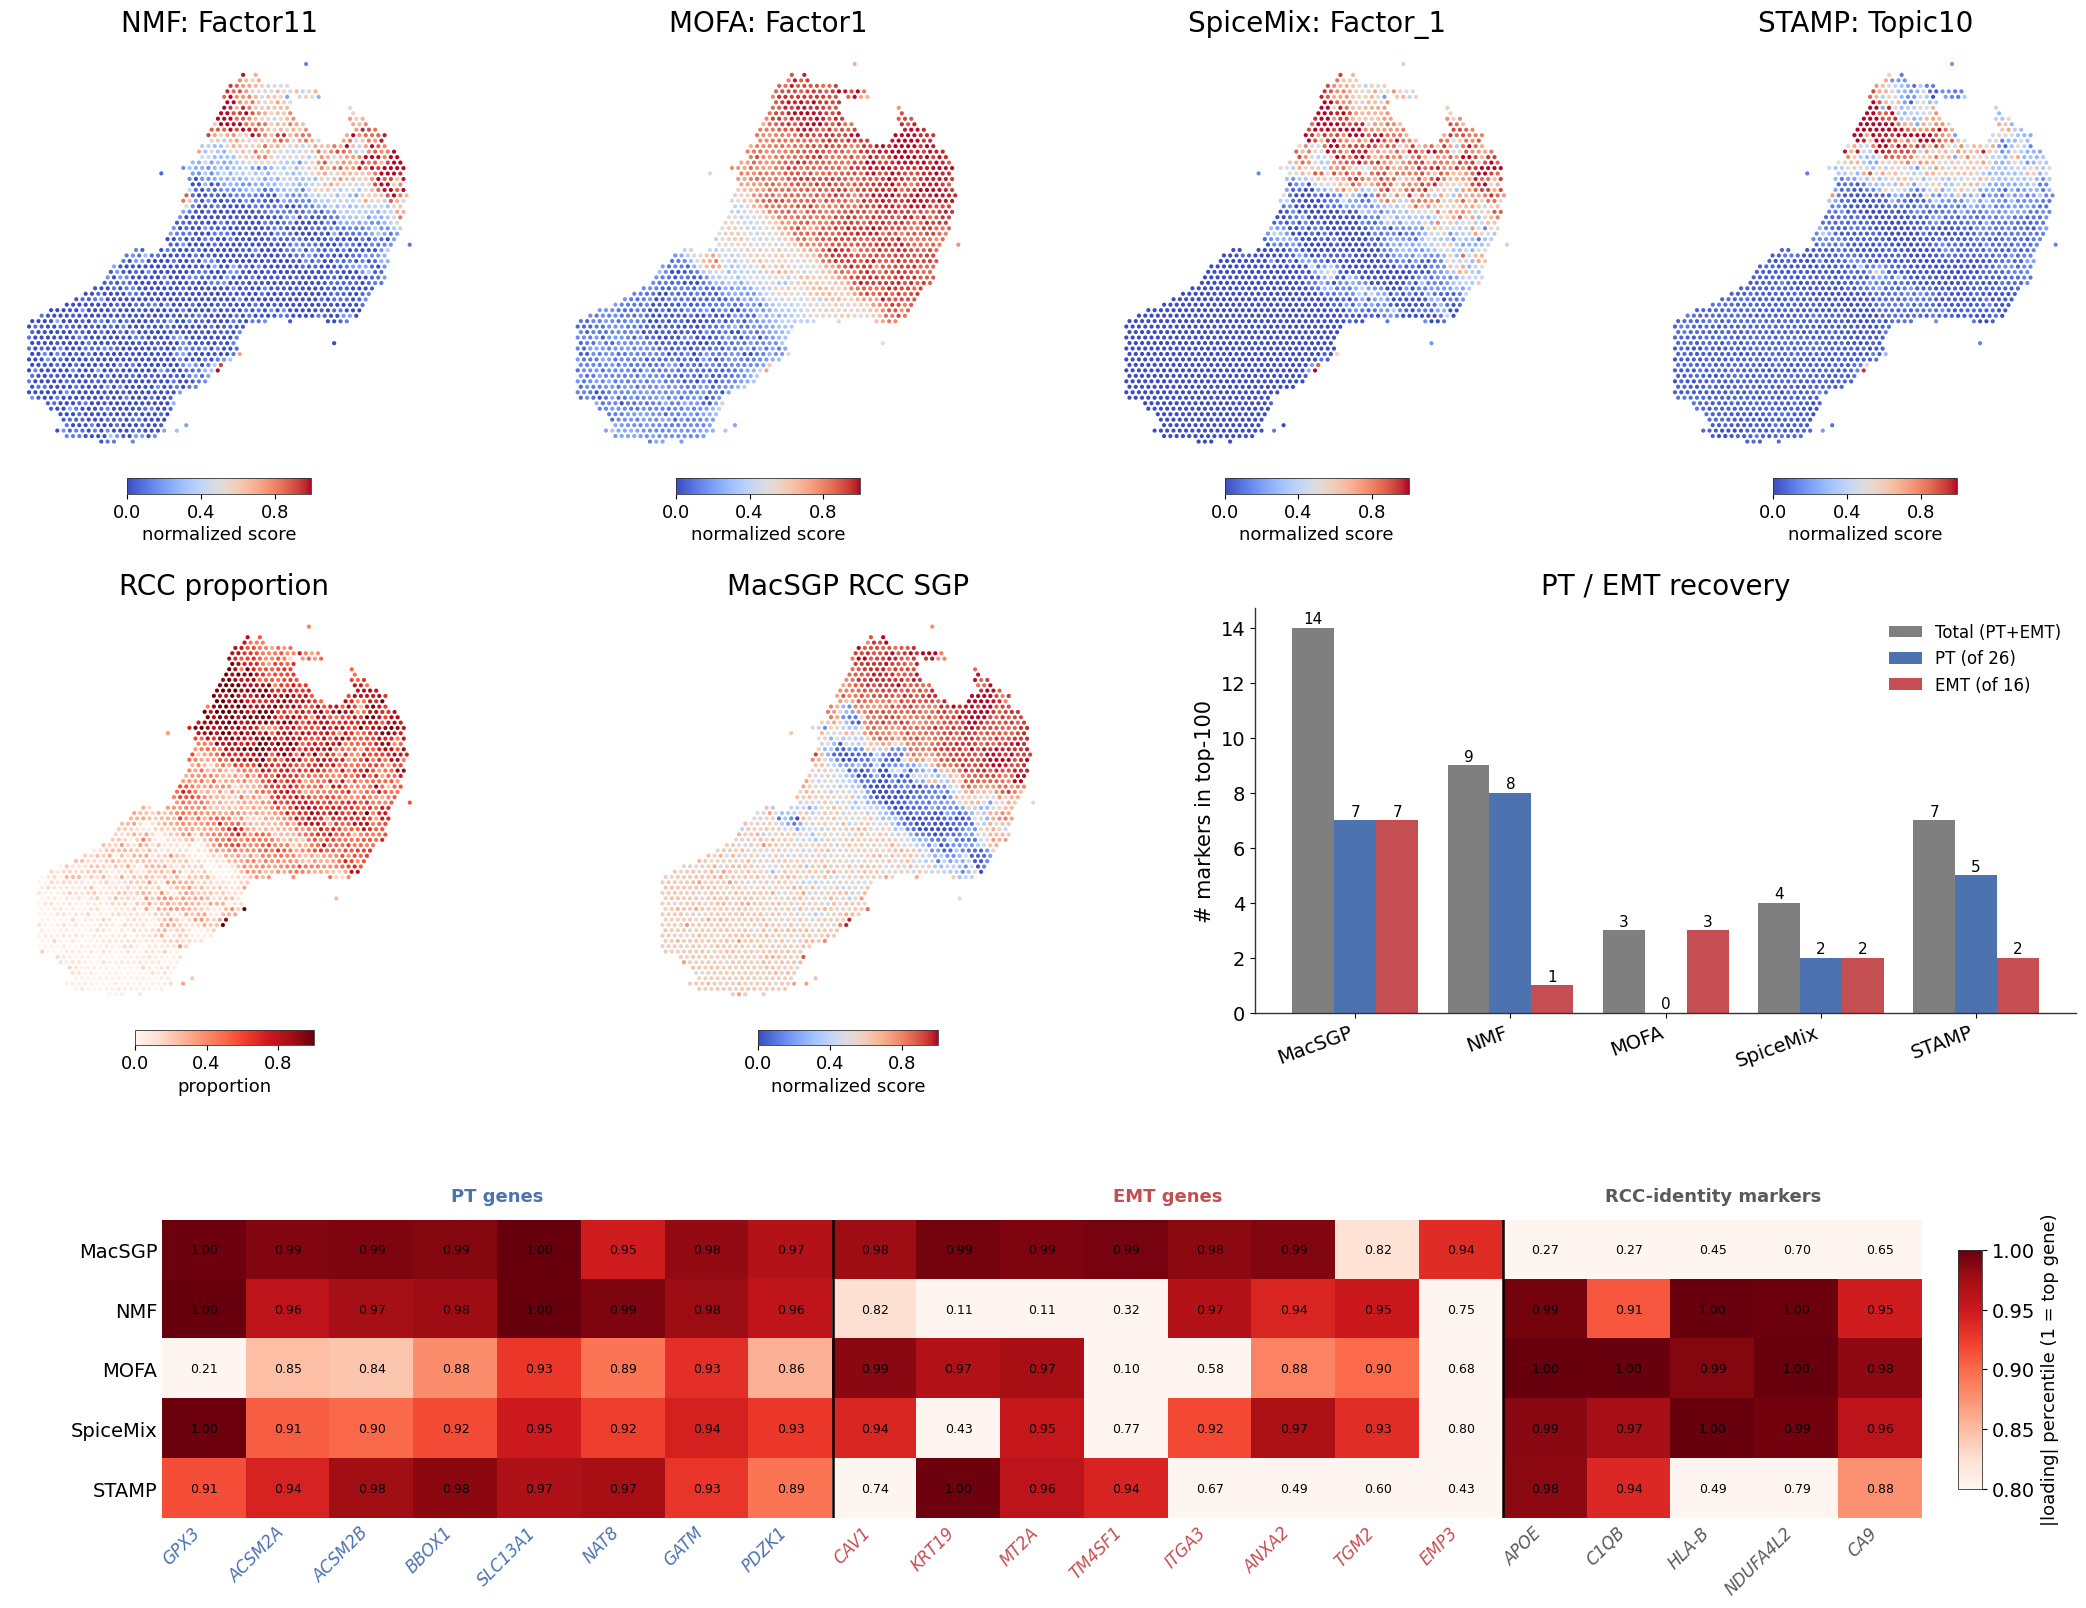

saved -> /import/home2/share/yqzeng/MacSGP/revision_2/vis/2.3/figs_factor/spatial_factor_panel.png


In [ ]:
def norm01(val):
    v=np.asarray(val,float); lo,hi=np.nanpercentile(v,[2,98])
    return np.clip((v-lo)/(hi-lo+1e-9),0,1)

def add_cbar(ax, sm, label=None):
    cax=ax.inset_axes([0.28,-0.08,0.44,0.038])
    cb=ax.figure.colorbar(sm,cax=cax,orientation="horizontal")
    cb.locator=MaxNLocator(nbins=3); cb.update_ticks(); cax.tick_params(labelsize=CBAR_FS)
    if label: cb.set_label(label,fontsize=CBAR_FS,labelpad=3)
    cb.outline.set_linewidth(0.6)
    return cb

def draw_score(ax, val, title, cmap="coolwarm", label="normalized score", spot=9):
    sm=ax.scatter(X_,Y_,c=norm01(val),cmap=cmap,s=spot,vmin=0,vmax=1,linewidths=0)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_title(title,fontsize=TITLE_FS,pad=10)
    add_cbar(ax,sm,label=label)
    return sm

fig=plt.figure(figsize=(22,17))
sf=fig.subfigures(3,1,height_ratios=[1.0,1.0,1.05],hspace=0.03)

# ---- Row 1: four baseline RCC-matched factor maps ----
a0=sf[0].subplots(1,4)
sf[0].subplots_adjust(left=0.03,right=0.97,top=0.90,bottom=0.14,wspace=0.30)
for ax,m in zip(a0,METHODS):
    bf,sgn=rcc_prog[m]
    draw_score(ax, sgn*FAC[m][bf].values.astype(float), f"{MLAB[m]}: {bf}")

# ---- Row 2: RCC proportion | MacSGP SGP | recovery bar ----
a1=sf[1].subplots(1,3,gridspec_kw={"width_ratios":[1,1,1.9]})
sf[1].subplots_adjust(left=0.03,right=0.97,top=0.90,bottom=0.16,wspace=0.34)
draw_score(a1[0], rcc_prop, "RCC proportion", cmap="Reds", label="proportion")
draw_score(a1[1], mac_fac,  "MacSGP RCC SGP")

axr=a1[2]
order=["MacSGP"]+[MLAB[m] for m in METHODS]
d=rec_tab.set_index("method").loc[order]
ptv=d["PT_recovered"].values; emtv=d["EMT_recovered"].values; tot=ptv+emtv
x=np.arange(len(order)); w=0.27
axr.bar(x-w,tot ,w,label="Total (PT+EMT)",color="#7f7f7f")
axr.bar(x  ,ptv ,w,label=f"PT (of {len(PT)})",color="#4c72b0")
axr.bar(x+w,emtv,w,label=f"EMT (of {len(EMT)})",color="#c44e52")
axr.set_xticks(x); axr.set_xticklabels(order,fontsize=BAR_TICK_FS,rotation=20,ha="right")
axr.set_ylabel(f"# markers in top-{TOPN}",fontsize=15)
axr.set_title("PT / EMT recovery",fontsize=TITLE_FS,pad=10)
axr.legend(frameon=False,fontsize=12,loc="upper right")
for xi in range(len(order)):
    axr.text(xi-w,tot[xi]+0.15 ,str(tot[xi]) ,ha="center",fontsize=11)
    axr.text(xi  ,ptv[xi]+0.15 ,str(ptv[xi]) ,ha="center",fontsize=11)
    axr.text(xi+w,emtv[xi]+0.15,str(emtv[xi]),ha="center",fontsize=11)

# ---- Row 3: gene x method |loading|-percentile heatmap ----
axh=sf[2].subplots(1,1)
sf[2].subplots_adjust(left=0.10,right=0.90,top=0.82,bottom=0.30)
PT_H =["GPX3","ACSM2A","ACSM2B","BBOX1","SLC13A1","NAT8","GATM","PDZK1"]
EMT_H=["CAV1","KRT19","MT2A","TM4SF1","ITGA3","ANXA2","TGM2","EMP3"]
ID_H =["APOE","C1QB","HLA-B","NDUFA4L2","CA9"]
groups=[("PT genes",PT_H,"#4c72b0"),("EMT genes",EMT_H,"#c44e52"),("RCC-identity markers",ID_H,"0.35")]
progs={"MacSGP":mac_load.abs()}
for m in METHODS:
    bf,_=rcc_prog[m]; progs[MLAB[m]]=LOAD[m][bf].abs()
hrows=["MacSGP"]+[MLAB[m] for m in METHODS]
pct={k:s.rank(pct=True) for k,s in progs.items()}
genes=[g for _,gs_,_ in groups for g in gs_]; gcol=[c for _,gs_,c in groups for _ in gs_]
Mh=np.array([[pct[k].get(g,np.nan) for g in genes] for k in hrows])
im=axh.imshow(Mh,aspect="auto",cmap='Reds',vmin=0.8,vmax=1)
axh.set_yticks(range(len(hrows))); axh.set_yticklabels(hrows,fontsize=14)
axh.set_xticks(range(len(genes)))
axh.set_xticklabels(genes,fontsize=12,rotation=45,ha="right",style="italic")
for t,c in zip(axh.get_xticklabels(),gcol): t.set_color(c)
for i in range(len(hrows)):
    for j in range(len(genes)):
        if not np.isnan(Mh[i,j]):
            # axh.text(j,i,f"{Mh[i,j]:.2f}",ha="center",va="center",fontsize=9,
            #          color="white" if (Mh[i,j]>0.82 or Mh[i,j]<0.18) else "black")
            axh.text(j,i,f"{Mh[i,j]:.2f}",ha="center",va="center",fontsize=9,
                     color="black")
            
x0=0
for name,gs_,col in groups:
    n=len(gs_)
    if x0>0: axh.axvline(x0-0.5,color="k",lw=1.8)
    axh.text(x0+n/2-0.5,-0.75,name,ha="center",va="bottom",fontsize=13,fontweight="bold",color=col)
    x0+=n
axh.set_ylim(len(hrows)-0.5,-0.5); axh.set_xlim(-0.5,len(genes)-0.5)
axh.tick_params(length=0)
for sp in axh.spines.values(): sp.set_visible(False)
cax=axh.inset_axes([1.02,0.10,0.014,0.80])
cb=fig.colorbar(im,cax=cax); cb.set_label("|loading| percentile (1 = top gene)",fontsize=CBAR_FS)
cb.outline.set_linewidth(0.6)

fig.savefig(os.path.join(FIG_DIR,"spatial_factor_panel.pdf"),bbox_inches="tight")
fig.savefig(os.path.join(FIG_DIR,"spatial_factor_panel.png"),dpi=300,bbox_inches="tight")
plt.show()
print("saved ->",os.path.join(FIG_DIR,"spatial_factor_panel.png"))